# Val/Test Divergence Curves

Plots per-epoch AUPRC on the synthetic val set vs the original test set for each model.

Generated by `anomaly_benchmark.py` → `divergence_curves.csv`.

**Interpreting the curves:**
- **Val (synthetic):** AUPRC on synthetic graph val nodes — what early stopping optimises.
- **Test (original):** AUPRC on original graph test nodes — the actual utility signal.
- The **divergence point** is where val keeps climbing while test plateaus or drops.
  A large gap indicates the synthetic graph does not faithfully capture the original's anomaly structure.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# --- Configure which run to analyse ---
GENERATOR      = 'bigg'
DATASET        = 'tolokers'
SYNTHETIC_NAME = 'blksize_-1_b_1_lr_0.0003_epochs_300_noise_0.3_ss_0.3_norm_cdf_bfs_lw_0.01_0.1_det_masked_vae16_kl0.5_sub15_size500_p0.7'

# Resolve project root — works whether Jupyter is launched from root or scripts/benchmark/
_cwd = Path.cwd()
PROJ_ROOT   = _cwd if (_cwd / 'scripts').exists() else (_cwd / '../..').resolve()
RESULTS_DIR = PROJ_ROOT / 'results' / 'evaluate' / GENERATOR / DATASET / SYNTHETIC_NAME
CURVES_PATH = RESULTS_DIR / 'divergence_curves.csv'
OUT_DIR     = RESULTS_DIR / 'divergence_plots'
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CURVES_PATH)
print(f'Curves: {len(df)} rows')
print(f'  sources:  {df.source.unique().tolist()}')
print(f'  datasets: {df.dataset.unique().tolist()}')
print(f'  models:   {df.model.unique().tolist()}')
df.head()

Curves: 1758 rows
  sources:  ['original', 'synthetic-graph', 'real-subsampled-graph']
  datasets: ['tolokers']
  models:   ['GCN', 'GIN', 'GraphSAGE']


,source,dataset,model,epoch,val_auprc_mean,val_auprc_std,test_auprc_mean,test_auprc_std
0,original,tolokers,GCN,0,0.277319,0.049126,0.274273,0.049301
1,original,tolokers,GCN,1,0.331961,0.034743,0.335657,0.036717
2,original,tolokers,GCN,2,0.335064,0.027592,0.335770,0.028361
3,original,tolokers,GCN,3,0.341480,0.021796,0.342375,0.021226
4,original,tolokers,GCN,4,0.348962,0.020564,0.350212,0.018604


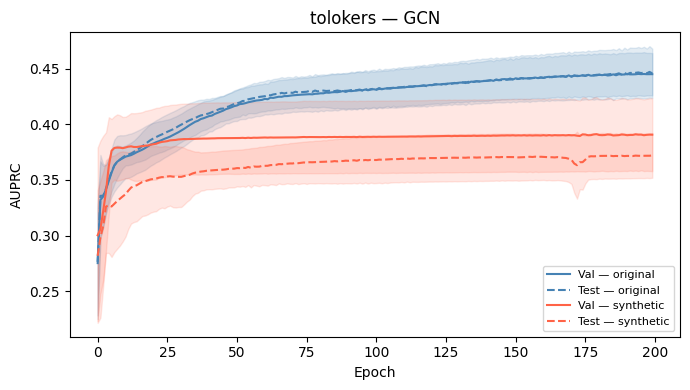

Saved /home/eirik/progg/master/SynBench/results/evaluate/bigg/tolokers/blksize_-1_b_1_lr_0.0003_epochs_300_noise_0.3_ss_0.3_norm_cdf_bfs_lw_0.01_0.1_det_masked_vae16_kl0.5_sub15_size500_p0.7/divergence_plots/tolokers_GCN.png


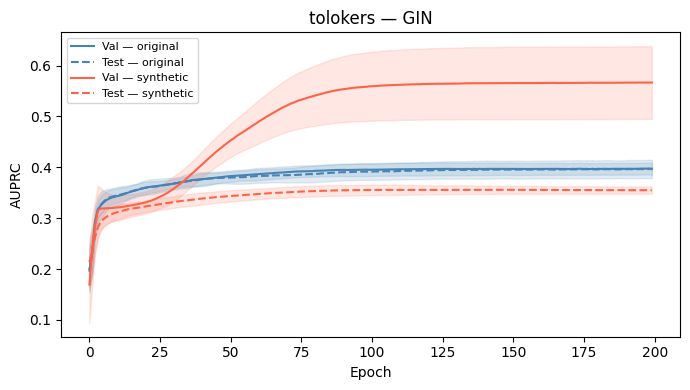

Saved /home/eirik/progg/master/SynBench/results/evaluate/bigg/tolokers/blksize_-1_b_1_lr_0.0003_epochs_300_noise_0.3_ss_0.3_norm_cdf_bfs_lw_0.01_0.1_det_masked_vae16_kl0.5_sub15_size500_p0.7/divergence_plots/tolokers_GIN.png


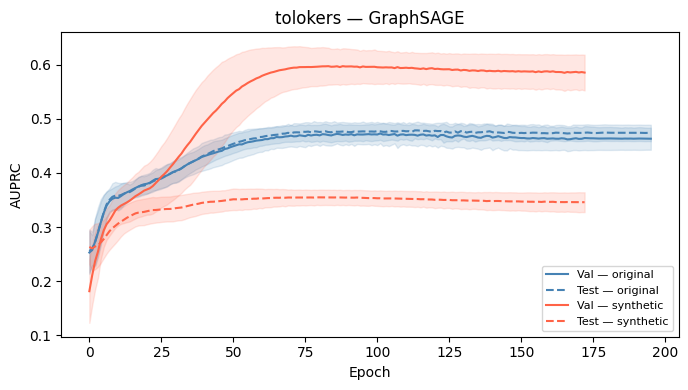

Saved /home/eirik/progg/master/SynBench/results/evaluate/bigg/tolokers/blksize_-1_b_1_lr_0.0003_epochs_300_noise_0.3_ss_0.3_norm_cdf_bfs_lw_0.01_0.1_det_masked_vae16_kl0.5_sub15_size500_p0.7/divergence_plots/tolokers_GraphSAGE.png


In [2]:
for (dataset, model), grp in df.groupby(['dataset', 'model']):
    orig = grp[grp['source'] == 'original']
    syn  = grp[grp['source'] == 'synthetic-graph']

    fig, ax = plt.subplots(figsize=(7, 4))

    if not orig.empty:
        ax.plot(orig['epoch'], orig['val_auprc_mean'],  label='Val — original',  color='steelblue',  linestyle='-')
        ax.fill_between(orig['epoch'],
                        orig['val_auprc_mean'] - orig['val_auprc_std'],
                        orig['val_auprc_mean'] + orig['val_auprc_std'],
                        alpha=0.15, color='steelblue')
        ax.plot(orig['epoch'], orig['test_auprc_mean'], label='Test — original', color='steelblue', linestyle='--')
        ax.fill_between(orig['epoch'],
                        orig['test_auprc_mean'] - orig['test_auprc_std'],
                        orig['test_auprc_mean'] + orig['test_auprc_std'],
                        alpha=0.15, color='steelblue')

    if not syn.empty:
        ax.plot(syn['epoch'], syn['val_auprc_mean'],  label='Val — synthetic',  color='tomato', linestyle='-')
        ax.fill_between(syn['epoch'],
                        syn['val_auprc_mean'] - syn['val_auprc_std'],
                        syn['val_auprc_mean'] + syn['val_auprc_std'],
                        alpha=0.15, color='tomato')
        ax.plot(syn['epoch'], syn['test_auprc_mean'], label='Test — synthetic', color='tomato', linestyle='--')
        ax.fill_between(syn['epoch'],
                        syn['test_auprc_mean'] - syn['test_auprc_std'],
                        syn['test_auprc_mean'] + syn['test_auprc_std'],
                        alpha=0.15, color='tomato')

    ax.set_xlabel('Epoch')
    ax.set_ylabel('AUPRC')
    ax.set_title(f'{dataset} — {model}')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    plt.tight_layout()

    out_path = OUT_DIR / f'{dataset}_{model}.png'
    plt.savefig(out_path, dpi=150)
    plt.show()
    plt.close(fig)
    print(f'Saved {out_path}')

In [3]:
# Divergence summary: at the epoch early stopping picks (peak val), what is test?
# val_test_gap > 0 means val overestimates true test performance at that checkpoint.
rows = []
for (dataset, model, source), sgrp in df.groupby(['dataset', 'model', 'source']):
    best_row     = sgrp.iloc[sgrp['val_auprc_mean'].values.argmax()]
    val_at_best  = best_row['val_auprc_mean']
    test_at_best = best_row['test_auprc_mean']
    rows.append({
        'dataset': dataset, 'model': model, 'source': source,
        'best_val_epoch': int(best_row['epoch']),
        'val_auprc':    val_at_best,
        'test_auprc':   test_at_best,
        'val_test_gap': val_at_best - test_at_best,
    })

summary = pd.DataFrame(rows).sort_values(['dataset', 'model', 'source'])
print('Summary — val_test_gap: how much val overestimates true test performance at early-stopping epoch')
summary.round(4)

Summary — val_test_gap: how much val overestimates true test performance at early-stopping epoch


,dataset,model,source,best_val_epoch,val_auprc,test_auprc,val_test_gap
0,tolokers,GCN,original,194,0.4452,0.4465,-0.0013
1,tolokers,GCN,real-subsampled-graph,172,0.5678,0.2891,0.2788
2,tolokers,GCN,synthetic-graph,179,0.3911,0.3713,0.0198
3,tolokers,GIN,original,198,0.3976,0.3968,0.0008
4,tolokers,GIN,real-subsampled-graph,195,0.5132,0.3018,0.2114
5,tolokers,GIN,synthetic-graph,199,0.5666,0.3549,0.2117
6,tolokers,GraphSAGE,original,101,0.4729,0.4769,-0.0040
7,tolokers,GraphSAGE,real-subsampled-graph,77,0.5738,0.3296,0.2441
8,tolokers,GraphSAGE,synthetic-graph,88,0.5973,0.3545,0.2428
